# Telecom Operator Efficiency Analysis
## Business Problem

Call center operations often show variability in operator performance.

The goal of this analysis is to identify inefficient operators based on missed calls, wait time, and call volume, and evaluate their potential impact on customer experience and operational efficiency.

This analysis also aims to uncover whether inefficiencies are isolated or systemic across clients and operators.

## Data Description

Two datasets were used:

- telecom_dataset_us.csv: call-level operational data
- telecom_clients_us.csv: client information

The data also includes information on call directions, duration, missed calls, ando operator assignment.

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
telecom = pd.read_csv('../data/telecom_dataset_new.csv')
clients = pd.read_csv('../data/telecom_clients.csv')

## Initial Data Inspection

In [5]:
telecom.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0000,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0000,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0000,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0000,True,3,0,25


In [7]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [9]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [11]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [13]:
telecom.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [17]:
clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [19]:
telecom.duplicated().sum(), clients.duplicated().sum()

(4900, 0)

## Data Merge

In [26]:
telecom_full = telecom.merge(clients, on='user_id', how='left')

In [28]:
telecom.shape, clients.shape, telecom_full.shape

((53902, 9), (732, 3), (53902, 11))

In [30]:
telecom_full.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0000,True,3,0,5,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0000,True,1,0,1,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0000,False,1,10,18,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0000,True,3,0,25,B,2019-08-01


## Data Cleaning

## Time Granularity Limitation

The 'date' column was analyzed to verify time-level granularity.

All the timestamps correspond to 00:00:00, indicating that the data is aggregated at the daily level.
This limits the ability to analyze intra-day performance patterns such as peak hours, operator shifts, or hourly inefficiencies.

Therefore, all time-based insights are evaluated at the daily level.

In [34]:
telecom_full['date'] = pd.to_datetime(telecom_full['date'], errors='coerce').dt.tz_localize(None).dt.date
telecom_full['date_start'] = pd.to_datetime(telecom_full['date_start'], errors='coerce').dt.date

Internal

In [37]:
telecom_full['internal'] = telecom_full['internal'].fillna(False).astype('bool')

C:\Users\marco\AppData\Local\Temp\ipykernel_4752\3623538771.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telecom_full['internal'] = telecom_full['internal'].fillna(False).astype('bool')


Operator_id

In [39]:
telecom_full['operator_id'] = pd.to_numeric(telecom_full['operator_id'], errors='coerce')
telecom_full['operator_id'] = telecom_full['operator_id'].astype('Int64').astype(str)
telecom_full['operator_id'] = telecom_full['operator_id'].replace('<NA>', 'unknown')

In [43]:
telecom_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              53902 non-null  int64 
 1   date                 53902 non-null  object
 2   direction            53902 non-null  object
 3   internal             53902 non-null  bool  
 4   operator_id          53902 non-null  object
 5   is_missed_call       53902 non-null  bool  
 6   calls_count          53902 non-null  int64 
 7   call_duration        53902 non-null  int64 
 8   total_call_duration  53902 non-null  int64 
 9   tariff_plan          53902 non-null  object
 10  date_start           53902 non-null  object
dtypes: bool(2), int64(4), object(5)
memory usage: 3.8+ MB


## Feature Engineering

## Wait Time
Wait time was approximated as the difference between total call duration and actual call duration, assuming that the remaining time reflects queue or handling delays.

In [48]:
telecom_full['wait_time'] = (
    telecom_full['total_call_duration'] - telecom_full['call_duration']
).clip(lower=0)

In [52]:
telecom_full['date_only'] = telecom_full['date']

In [58]:
telecom_full['date_only'] = pd.to_datetime(telecom_full['date'])
telecom_full['date_start'] = pd.to_datetime(telecom_full['date_start'])

telecom_full['days_since_start'] = (
    telecom_full['date_only'] - telecom_full['date_start']
).dt.days

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              53902 non-null  int64         
 1   date                 53902 non-null  object        
 2   direction            53902 non-null  object        
 3   internal             53902 non-null  bool          
 4   operator_id          53902 non-null  object        
 5   is_missed_call       53902 non-null  bool          
 6   calls_count          53902 non-null  int64         
 7   call_duration        53902 non-null  int64         
 8   total_call_duration  53902 non-null  int64         
 9   tariff_plan          53902 non-null  object        
 10  date_start           53902 non-null  datetime64[ns]
 11  wait_time            53902 non-null  int64         
 12  date_only            53902 non-null  datetime64[ns]
 13  days_since_start     53902 non-

## Missed Incoming

In [64]:
telecom_full['missed_incoming'] = (
    (telecom_full['direction'] == 'in') &
    (telecom_full['is_missed_call'] == True)
)

## Missed Outgoing

In [67]:
telecom_full['missed_outgoing'] = (
    (telecom_full['direction'] == 'out') &
    (telecom_full['is_missed_call'] == True)
)

## EDA

In [70]:
telecom_full[['calls_count', 'call_duration', 'total_call_duration', 'wait_time', 'days_since_start']].describe()

,calls_count,call_duration,total_call_duration,wait_time,days_since_start
count,53902.0000,53902.0000,53902.0000,53902.0000,53902.0000
mean,16.4512,866.6844,1157.1333,290.4489,44.0064
std,62.9172,3731.7912,4403.4688,1127.9057,27.0106
min,1.0000,0.0000,0.0000,0.0000,0.0000
25%,1.0000,0.0000,47.0000,17.0000,22.0000
50%,4.0000,38.0000,210.0000,55.0000,40.0000
75%,12.0000,572.0000,902.0000,201.0000,63.0000
max,4817.0000,144395.0000,166155.0000,46474.0000,119.0000


## Direction Distribution

In [75]:
telecom_full['direction'].value_counts()

direction
out    31917
in     21985
Name: count, dtype: int64

In [ ]:
#8.4

In [ ]:
pd.Series({
    'missed_incoming_calls': telecom_full.loc[telecom_full['missed_incoming'], 'calls_count'].sum(),
    'missed_outgoing_calls': telecom_full.loc[telecom_full['missed_outgoing'], 'calls_count'].sum()
})

## Call Duration Distribution

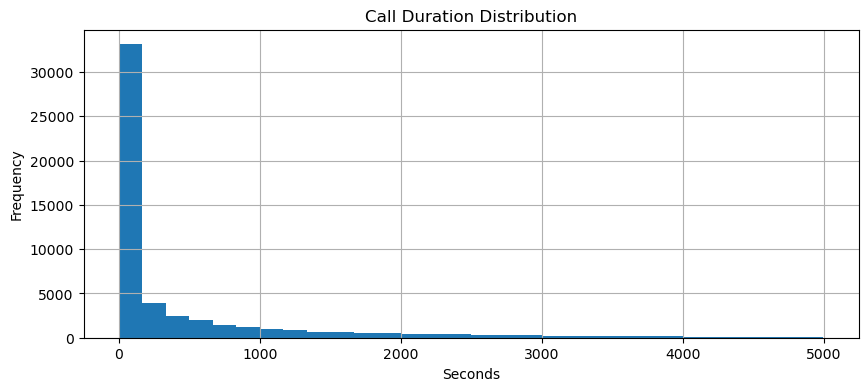

In [83]:
plt.figure(figsize=(10, 4))
telecom_full.loc[telecom_full['call_duration'] < 5000, 'call_duration'].hist(bins=30)
plt.title('Call Duration Distribution')
plt.xlabel('Seconds')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Total Calls Per Day

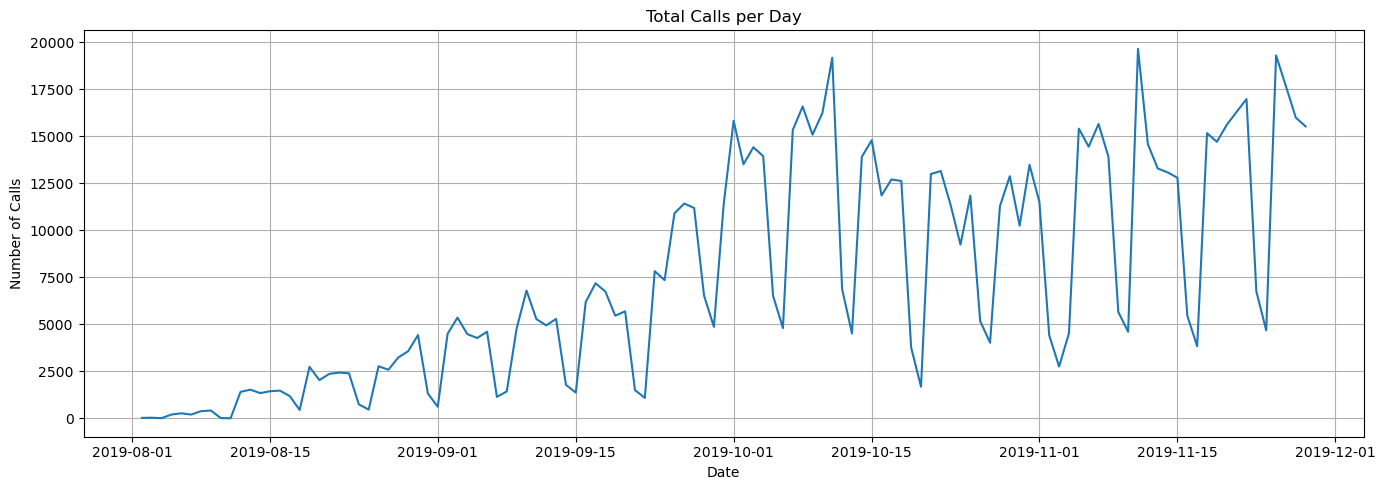

In [90]:
calls_per_day = telecom_full.groupby('date')['calls_count'].sum()

plt.figure(figsize=(14, 5))
calls_per_day.plot()
plt.title('Total Calls per Day')
plt.xlabel('Date')
plt.ylabel('Number of Calls')
plt.grid(True)
plt.tight_layout()
plt.show()

## Incoming vs Outgoing Calls

In [93]:
direction_volume = telecom_full.groupby('direction')['calls_count'].sum()
direction_volume

direction
in     216863
out    669892
Name: calls_count, dtype: int64

## Direction PCT

In [96]:
direction_pct = direction_volume / direction_volume.sum()
direction_pct

direction
in    0.2446
out   0.7554
Name: calls_count, dtype: float64

## Missed Ratio

In [100]:
direction_missed = telecom_full.groupby('direction').apply(
    lambda df: pd.Series({
        'total_calls': df['calls_count'].sum(),
        'missed_calls': df.loc[df['is_missed_call'], 'calls_count'].sum()
    })
)

direction_missed['missed_ratio'] = (
    direction_missed['missed_calls'] / direction_missed['total_calls']
)

direction_missed

C:\Users\marco\AppData\Local\Temp\ipykernel_4752\3111072001.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  direction_missed = telecom_full.groupby('direction').apply(


,total_calls,missed_calls,missed_ratio
direction,,,
in,216863,113464,0.5232
out,669892,298841,0.4461


## Clients Behavior

In [105]:
client_direction = telecom_full.groupby(['user_id', 'direction'])['calls_count'].sum().unstack().fillna(0)

client_direction.columns = ['incoming_calls', 'outgoing_calls']

client_direction.head()

,incoming_calls,outgoing_calls
user_id,,
166377,214.0000,5528.0000
166391,26.0000,1.0000
166392,243.0000,0.0000
166399,28.0000,0.0000
166405,8482.0000,10700.0000


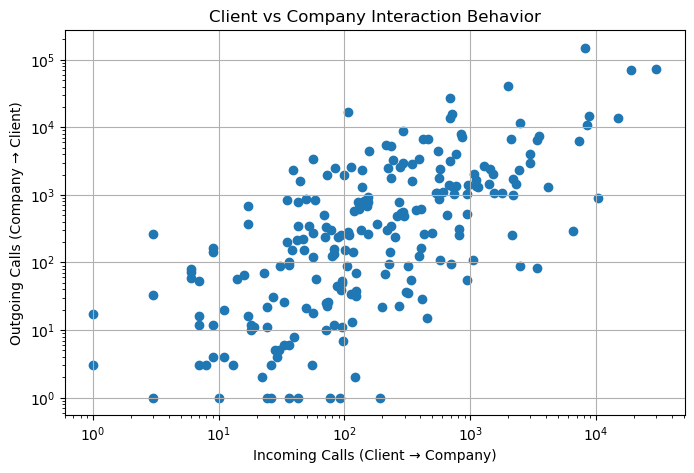

In [114]:
plt.figure(figsize=(8,5))

plt.scatter(
    client_direction['incoming_calls'],
    client_direction['outgoing_calls']
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Incoming Calls (Client → Company)')
plt.ylabel('Outgoing Calls (Company → Client)')
plt.title('Client vs Company Interaction Behavior')
plt.grid(True)

plt.show()

In [118]:
telecom_full['days_since_start'] = (
    telecom_full['date_only'] - telecom_full['date_start']
).dt.days

In [120]:
client_calls = (
    telecom_full
    .groupby(['user_id', 'direction'])['calls_count']
    .sum()
    .unstack()
    .fillna(0)
)

client_calls.columns = ['incoming_calls', 'outgoing_calls']
client_calls = client_calls.reset_index()

In [122]:
client_age = (
    telecom_full
    .groupby('user_id')['days_since_start']
    .max()
    .reset_index(name='days_active')
)

In [124]:
client_behavior = client_calls.merge(client_age, on='user_id')

In [126]:
client_behavior['incoming_per_day'] = (
    client_behavior['incoming_calls'] / client_behavior['days_active']
)

client_behavior['outgoing_per_day'] = (
    client_behavior['outgoing_calls'] / client_behavior['days_active']
)

In [128]:
client_behavior['total_calls'] = (
    client_behavior['incoming_calls'] + client_behavior['outgoing_calls']
)

In [130]:
client_behavior

,user_id,incoming_calls,outgoing_calls,days_active,incoming_per_day,outgoing_per_day,total_calls
0,166377,214.0000,5528.0000,119,1.7983,46.4538,5742.0000
1,166391,26.0000,1.0000,113,0.2301,0.0088,27.0000
2,166392,243.0000,0.0000,119,2.0420,0.0000,243.0000
3,166399,28.0000,0.0000,83,0.3373,0.0000,28.0000
4,166405,8482.0000,10700.0000,118,71.8814,90.6780,19182.0000
...,...,...,...,...,...,...,...
302,168583,49.0000,0.0000,28,1.7500,0.0000,49.0000
303,168598,111.0000,0.0000,28,3.9643,0.0000,111.0000
304,168601,130.0000,614.0000,28,4.6429,21.9286,744.0000
305,168603,1.0000,17.0000,28,0.0357,0.6071,18.0000


In [132]:
incoming_calls = telecom_full[
    telecom_full['direction'] == 'in'
].copy()

outgoing_calls = telecom_full[
    telecom_full['direction'] == 'out'
].copy()

In [136]:
# Cliente → compañía
first_incoming = (
    incoming_calls
    .groupby('user_id')['date_only']
    .min()
    .reset_index(name='first_incoming_date')
)

# Compañía → cliente
first_outgoing = (
    outgoing_calls
    .groupby('user_id')['date_only']
    .min()
    .reset_index(name='first_outgoing_date')
)

In [140]:
client_start = (
    telecom_full[['user_id', 'date_start']]
    .drop_duplicates()
)

In [142]:
client_timing = client_start \
    .merge(first_incoming, on='user_id', how='left') \
    .merge(first_outgoing, on='user_id', how='left')

In [144]:
client_timing['days_to_incoming'] = (
    client_timing['first_incoming_date'] - client_timing['date_start']
).dt.days

client_timing['days_to_outgoing'] = (
    client_timing['first_outgoing_date'] - client_timing['date_start']
).dt.days

In [146]:
client_timing = client_timing[
    (client_timing['days_to_incoming'].isna() | (client_timing['days_to_incoming'] >= 0)) &
    (client_timing['days_to_outgoing'].isna() | (client_timing['days_to_outgoing'] >= 0))
]

In [148]:
client_timing[['days_to_incoming', 'days_to_outgoing']].mean()

days_to_incoming    6.8762
days_to_outgoing   12.5766
dtype: float64

In [150]:
client_timing[['days_to_incoming', 'days_to_outgoing']].median()

days_to_incoming   3.0000
days_to_outgoing   7.0000
dtype: float64

In [152]:
client_timing[['days_to_incoming', 'days_to_outgoing']].describe()

,days_to_incoming,days_to_outgoing
count,307.0000,222.0000
mean,6.8762,12.5766
std,10.0550,15.8586
min,0.0000,0.0000
25%,1.0000,2.0000
50%,3.0000,7.0000
75%,8.0000,16.0000
max,66.0000,98.0000


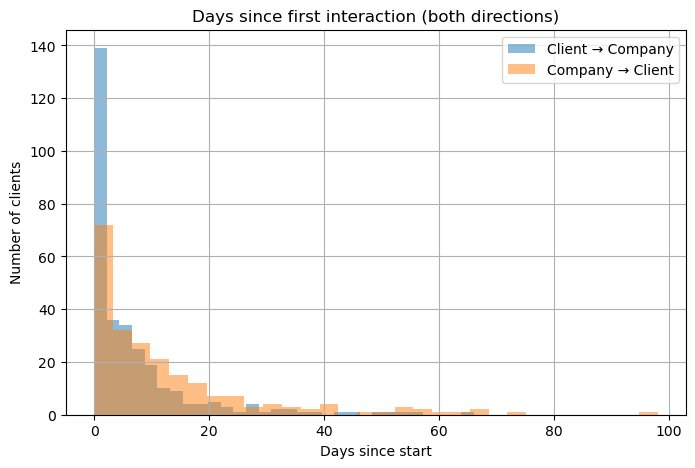

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(client_timing['days_to_incoming'].dropna(), bins=30, alpha=0.5, label='Client → Company')
plt.hist(client_timing['days_to_outgoing'].dropna(), bins=30, alpha=0.5, label='Company → Client')

plt.xlabel('Days since start')
plt.ylabel('Number of clients')
plt.title('Days since first interaction (both directions)')
plt.legend()
plt.grid(True)

plt.show()

In [162]:
client_timing['interaction_gap'] = (
    client_timing['days_to_outgoing'] - client_timing['days_to_incoming']
)

In [164]:
client_timing['interaction_gap'].mean()

5.6891891891891895

## Operator Stats

In [172]:
operator_stats = telecom_full.groupby('operator_id').apply(
    lambda df: pd.Series({
        'total_calls': df['calls_count'].sum(),
        'incoming_calls': df.loc[df['direction'] == 'in', 'calls_count'].sum(),
        'outgoing_calls': df.loc[df['direction'] == 'out', 'calls_count'].sum(),
        'missed_incoming_calls': df.loc[df['missed_incoming'], 'calls_count'].sum(),
        'avg_wait_time': df['wait_time'].sum() / df['calls_count'].sum(),
        'avg_call_duration': df['call_duration'].sum() / df['calls_count'].sum(),
        'avg_total_call_duration': df['total_call_duration'].sum() / df['calls_count'].sum()
    })
).reset_index()

operator_stats['incoming_missed_ratio'] = (
    operator_stats['missed_incoming_calls'] / operator_stats['incoming_calls']
)

operator_stats = operator_stats.replace([np.inf, -np.inf], np.nan)

C:\Users\marco\AppData\Local\Temp\ipykernel_4752\2026105745.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  operator_stats = telecom_full.groupby('operator_id').apply(


In [174]:
operator_stats 

,operator_id,total_calls,incoming_calls,outgoing_calls,missed_incoming_calls,avg_wait_time,avg_call_duration,avg_total_call_duration,incoming_missed_ratio
0,879896,1131.0000,60.0000,1071.0000,0.0000,12.5252,73.6172,86.1424,0.0000
1,879898,7974.0000,118.0000,7856.0000,0.0000,14.1675,34.9734,49.1410,0.0000
2,880020,54.0000,8.0000,46.0000,0.0000,6.1852,42.4074,48.5926,0.0000
3,880022,219.0000,8.0000,211.0000,0.0000,19.9772,83.5799,103.5571,0.0000
4,880026,2439.0000,25.0000,2414.0000,0.0000,9.8368,69.5670,79.4039,0.0000
...,...,...,...,...,...,...,...,...,...
1088,972412,61.0000,1.0000,60.0000,0.0000,17.2131,57.3443,74.5574,0.0000
1089,972460,70.0000,2.0000,68.0000,0.0000,11.4429,33.1571,44.6000,0.0000
1090,973120,3.0000,0.0000,3.0000,0.0000,6.6667,1.6667,8.3333,NaN
1091,973286,2.0000,2.0000,0.0000,0.0000,44.0000,8.5000,52.5000,0.0000


In [196]:
operator_stats.sort_values(by='incoming_missed_ratio', ascending=False).head(20)

,operator_id,total_calls,incoming_calls,outgoing_calls,missed_incoming_calls,avg_wait_time,avg_call_duration,avg_total_call_duration,incoming_missed_ratio
916,948756,176.0000,1.0000,175.0000,1.0000,8.7273,76.0852,84.8125,1.0000
1092,unknown,113716.0000,113167.0000,549.0000,112453.0000,12.0545,4.7440,16.7985,0.9937
242,904344,12.0000,7.0000,5.0000,6.0000,8.4167,22.7500,31.1667,0.8571
367,913886,2.0000,2.0000,0.0000,1.0000,13.5000,19.0000,32.5000,0.5000
272,906392,80.0000,19.0000,61.0000,7.0000,10.7375,32.6500,43.3875,0.3684
643,934098,6.0000,6.0000,0.0000,2.0000,26.5000,7.5000,34.0000,0.3333
682,937432,28.0000,3.0000,25.0000,1.0000,7.3214,6.9643,14.2857,0.3333
999,957922,23.0000,3.0000,20.0000,1.0000,16.7826,357.8696,374.6522,0.3333
282,906412,354.0000,26.0000,328.0000,7.0000,9.7712,52.7147,62.4859,0.2692
469,919896,8.0000,8.0000,0.0000,2.0000,13.6250,92.3750,106.0000,0.2500


In [176]:
operator_stats_filtered = operator_stats[
    operator_stats['incoming_calls'] >= 20
].copy()

operator_stats_filtered['volume_group'] = pd.qcut(
    operator_stats_filtered['incoming_calls'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

operator_stats_filtered.groupby('volume_group')[
    ['incoming_missed_ratio', 'avg_wait_time']
].mean()

C:\Users\marco\AppData\Local\Temp\ipykernel_4752\1900862213.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  operator_stats_filtered.groupby('volume_group')[


,incoming_missed_ratio,avg_wait_time
volume_group,,
Low,0.0186,18.3755
Medium,0.0128,15.9385
High,0.0203,16.4915


In [186]:
client_timing['first_contact_group'] = pd.cut(
    client_timing['days_to_incoming'],
    bins=[-1, 3, 7, 999],
    labels=['0-3 days', '4-7 days', '8+ days']
)

client_behavior_timing = client_behavior.merge(
    client_timing[['user_id', 'days_to_incoming', 'days_to_outgoing', 'first_contact_group']],
    on='user_id',
    how='left'
)

client_behavior_timing.groupby('first_contact_group')[
    ['incoming_calls', 'outgoing_calls', 'total_calls', 'incoming_per_day', 'outgoing_per_day']
].mean()

C:\Users\marco\AppData\Local\Temp\ipykernel_4752\4184512323.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  client_behavior_timing.groupby('first_contact_group')[


,incoming_calls,outgoing_calls,total_calls,incoming_per_day,outgoing_per_day
first_contact_group,,,,,
0-3 days,914.8868,3026.8994,3941.7862,21.1422,57.0126
4-7 days,431.8413,1271.9524,1703.7937,7.4691,23.6395
8+ days,519.8824,1276.2588,1796.1412,6.8415,22.8115


In [188]:
client_behavior['interaction_type'] = 'Balanced'

client_behavior.loc[
    client_behavior['incoming_calls'] >= 2 * client_behavior['outgoing_calls'],
    'interaction_type'
] = 'Client-driven'

client_behavior.loc[
    client_behavior['outgoing_calls'] >= 2 * client_behavior['incoming_calls'],
    'interaction_type'
] = 'Company-driven'

client_behavior['interaction_type'].value_counts()

interaction_type
Client-driven     149
Company-driven     94
Balanced           64
Name: count, dtype: int64

## Key Findings

- Operator inefficiency should be evaluated using missed incoming calls, as missed outbound calls often reflect unresponsive customers rather than operator performance.
- The relationship betqeen operator workload and inefficiency is non-linear.
  Medium_volume operators show the lowest missed incoming ratios, while both low and high-volume
  groups perform slightly worse. This suggests that inefficiency is not driven solely by call volume,
  but likely by operational factors such as workload distribution, training, or routing logic.
- The presence of a large number of calls associated with 'unknown' operator IDs represents a
  critical data quality and operational risk. While it is not possible to attribute these calls to
  specific operators, this lack of traceability may indicate gaps in call assignment, system tracking
  failures, or unmonitored iteractions. This can lead to missed incoming calls without
  accountability, reduced follow-up capability, and increased customer frustration.
- Customers who contact the company within the first 0-3 days after registration show significantly
  higher interaction volume and daily contact intensity. THis indicates that the onboarding period is
  a high-friction stage, where customers are more likely to experience issues, confusion, or unmet
  expectations.
- Most customers fall into a client-driven interaction pattern, meaning they initiate significantly
  more contact then they receive. This suggests that customer support demand is primarily reactive
  and driven by client needs rather than proactive engagement.
- A meaningful subser of customers is company-driven, indicating frequent outbound contact. This
  behavior may be associated with follow-up processes, unresolved tickets, retention efforts, payment
  collection, or marketing campaigns.
- Customers tend to contact the compay earlier than the company contacts them. On average, there is a
  delay of approximately 5-6 days between the first inbound and first outbound interaction,
  indicating a predominantly reactive service model with limited proactive onboarding.
- Outbound calls represent the majority of total interaction volume, confirming that the company
  plays a major role driving customer contact. However, this outbound activity likely reflects a mix
  of follow-up, operational processes, and campaign-driven outreach rather than purely proactive
  customer care. care.


## Recommendations

- Redefine operator performance metrics to focus on missed incomign calls only, ensuring a fair and
  accurate evaluation of operator efficiency.
- Implement minimum inbound activity thresholds when analyzing operator performance to avoid bias
  from low-volume operators.
- Investigate and resolve the issue of 'unknown' operator IDs. Improve data tracking systems to
  ensure all calls are properly attributed, enabling accountability, better performance monitoring,
  and more effective operational control.
- Strengthen monitoring and alert systems for missed incoming calls, particularly for operators or
  groups showing consistently high ratios.
- Prioritize the first 3 days after customer onboarding as a critical intervention window. Implement
  proactive onboarding strategies such as welcome calls, guided activation, or early support outreach
  to reduce initial friction.
- Conduct a cross-functional review (Customer Service + Markenting) to classify outbound calls into
  categories(follow-up, retention, campaigns, collections) and evaluate their effectivness and
  customer impact.
- Analyze whether company-driven interactions are associated with unresolved issues, excessive follow
  ups, or potentially intrusive campaigns, and optimize these proesses accordingly.
- Improve call routing and workload distribution to nesure that no subset of operators is
  disproportionatley exposed to high-demand or high-risk interactions.
- Link interaction patterns with customer satisfaction indicators (complaints, reviews, NPS) and long-
  term metrics such as Customer Lifetime Value (CLTV) to quantify the business imapact or operational
  inefficiencies.
- Establish continuous monitoring dashboards to track key metrics such as missed incoming ratio, wait
  time, first contact timing, and iteraction type, enabling proactive detection of operational issues. issues.


In [205]:
telecom_full.to_csv(
    r'C:\Users\marco\Desktop\Marco Data (Profesional)\Portafolio\telecom_operator_efficiency_analysis\data_export\tableau\telecom_full.csv',
    index=False
)

client_behavior.to_csv(
    r'C:\Users\marco\Desktop\Marco Data (Profesional)\Portafolio\telecom_operator_efficiency_analysis\data_export\tableau\client_behavior.csv',
    index=False
)

client_timing.to_csv(
    r'C:\Users\marco\Desktop\Marco Data (Profesional)\Portafolio\telecom_operator_efficiency_analysis\data_export\tableau\client_timing.csv',
    index=False
)

operator_stats_clean = operator_stats[
    operator_stats['operator_id'] != 'unknown'
].copy()

operator_stats_clean.to_csv(
    r'C:\Users\marco\Desktop\Marco Data (Profesional)\Portafolio\telecom_operator_efficiency_analysis\data_export\tableau\operator_stats.csv',
    index=False
)

client_full = client_behavior.merge(
    client_timing,
    on='user_id',
    how='left'
)

client_full.to_csv(
    r'C:\Users\marco\Desktop\Marco Data (Profesional)\Portafolio\telecom_operator_efficiency_analysis\data_export\tableau\client_full.csv',
    index=False
)